/Users/keerthi/anaconda3/lib/python3.13/site-packages/symfit/core/printing.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


(0.0, 1.052773047404433)

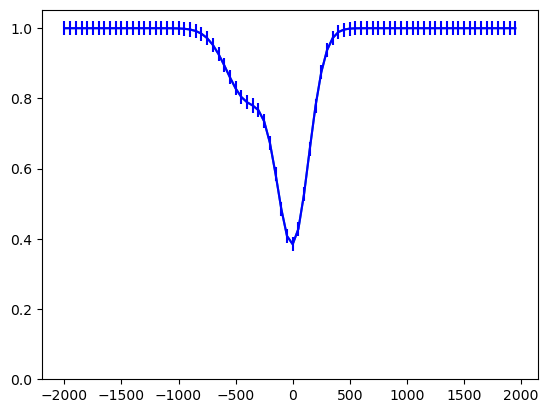

In [1]:
from ISMgas.fitting.DoubleGaussian import DoubleGaussian
import matplotlib.pyplot as plt
import numpy as np

## Generate some mock data 
x = np.arange(-2000,2000,50)
y = 1-0.6*np.exp(-((x+0)/200)**2) -0.2*np.exp(-((x+400)/250)**2)
yerr = 0.02*np.ones(len(x))

plt.plot(x,y)
plt.errorbar(
    x = x,
    y = y,
    yerr= yerr,
    color = 'blue',
)
plt.ylim([0,None])

In [57]:
dd = DoubleGaussian(
    x = x, 
    y = y, 
    yerr = yerr
)

fitResults = dd.fitting(seed=1345)
fitResultsSG = dd.fitting(seed=1345, double_gaussian = False)

(0.0, 1.030773047404433)

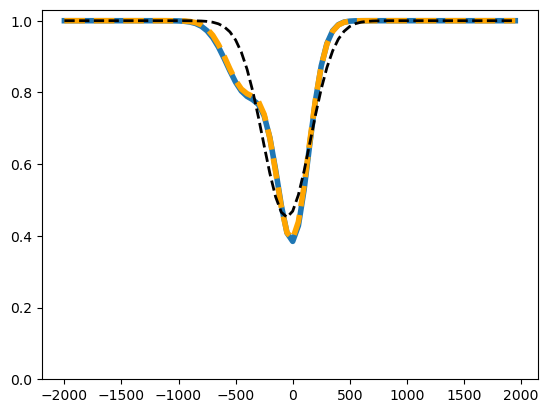

In [58]:
plt.plot(x,y, linewidth= 4, label='data')
plt.plot(fitResults['fitted_wav'],fitResults['fitted_flux'],color='orange', linestyle = '--',linewidth = 4, label='double Gaussian fit')
plt.plot(fitResultsSG['fitted_wav'],fitResultsSG['fitted_flux'],color='black', linestyle = '--',linewidth = 2, label = 'single Gaussian fit')

plt.ylim([0,None])

In [61]:
fitResults['derived_results']

{'v01': -703,
 'v05': -557,
 'v10': -464,
 'v25': -256,
 'v50': -71,
 'v75': 54,
 'v90': 153,
 'v95': 210,
 'v99': 314,
 'delta_v98': 1017,
 'delta_v90': 767,
 'delta_v80': 617,
 'delta_v50': 310,
 'EW_kms': 296.2385898686348}

In [62]:
fitResultsSG['derived_results']

{'v01': -536,
 'v05': -395,
 'v10': -319,
 'v25': -193,
 'v50': -53,
 'v75': 87,
 'v90': 213,
 'v95': 289,
 'v99': 431,
 'delta_v98': 967,
 'delta_v90': 684,
 'delta_v80': 532,
 'delta_v50': 280,
 'EW_kms': 285.537174047623}

## Uncertainity

To quantify the uncertainty in each parameter, we fit each profile with N realizations.

In [49]:
from ISMgas.SupportingFunctions import save_as_pickle

Nruns = 10
seeds = list(range(0,Nruns))
for seed in seeds:
    dd = DoubleGaussian(
        x = x, 
        y = y, 
        yerr = yerr
    )
    
    fitResults = dd.fitting(seed=seed)

    ## Save fit result to pkl file
    save_as_pickle(fitResults, f"Fits/fit_{seed}.pkl")
    

file saved to: Fits/fit_0.pkl
file saved to: Fits/fit_1.pkl
file saved to: Fits/fit_2.pkl
file saved to: Fits/fit_3.pkl
file saved to: Fits/fit_4.pkl
file saved to: Fits/fit_5.pkl
file saved to: Fits/fit_6.pkl
file saved to: Fits/fit_7.pkl
file saved to: Fits/fit_8.pkl
file saved to: Fits/fit_9.pkl


From the Nruns, we will measure the median and Median Absolute Deviation (MAD) values which we adopt as our measurement and our 1sigma uncertainity. 

The unWrapFittingResults class will handle this post processing step.

In [3]:
from ISMgas.fitting.DoubleGaussian import unWrapFittingResults

Nruns = 10
seeds = list(range(0,Nruns))

fitResult = unWrapFittingResults(
    seeds = seeds, 
    double_gaussian = True,
    folderName = "Fits/",
    objid="fit"
)
resultDict = fitResult.saveResults() ## Save the computed results to .pkl file

resultDict


Making diagonistics plots...
Saved initial fits histogram to Initial-fits-histogram-DG.png
Saved final fits histogram to All-fits-histogram-DG.png
Saved deconvolved final fits histogram to All-fits-deconvolved-histogram-DG.png
Saved deconvolved derived measurements to derived-measurements-histogram-DG.png
Saved deconvolved derived measurements to derived-measurements-deconvolved-histogram-DG.png


/Users/keerthi/anaconda3/lib/python3.13/site-packages/astropy/stats/histogram.py:227: RuntimeWarning: invalid value encountered in scalar divide
  Nbins = np.ceil((data.max() - data.min()) / dx)
/Users/keerthi/anaconda3/lib/python3.13/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/keerthi/anaconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2065: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/keerthi/anaconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2065: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


Saved derived outflow measurements to  derived-measurements-onlyoutflow-histogram-DG.png
file saved to: fit-DG-Results.pkl


{'objid': 'fit',
 'A_out': 0.2118311221789233,
 'A_out_sig': 0.028342574209264587,
 'A1_out': 0.5857113843256365,
 'A1_out_sig': 0.030379796640960324,
 'sig_out': 174.370262293825,
 'sig_out_sig': 19.91241415654056,
 'sig1_out': 144.37775059279838,
 'sig1_out_sig': 11.255271940462862,
 'v_out': -377.4240338714998,
 'v_out_sig': 52.62496714622523,
 'v1_out': -0.6953355112887019,
 'v1_out_sig': 9.943026992757815,
 'v01': -725.0,
 'v01sig': 14.814814814814813,
 'v05': -564.5,
 'v05sig': 20.0,
 'v10': -471.0,
 'v10sig': 14.814814814814813,
 'v25': -263.0,
 'v25sig': 10.37037037037037,
 'v99': 316.5,
 'v99sig': 20.0,
 'v95': 212.5,
 'v95sig': 13.333333333333332,
 'v90': 156.0,
 'v90sig': 10.37037037037037,
 'v75': 54.0,
 'v75sig': 3.7037037037037033,
 'delta_v98': 1045.0,
 'delta_v98sig': 29.629629629629626,
 'delta_v90': 783.0,
 'delta_v90sig': 18.51851851851852,
 'delta_v80': 630.0,
 'delta_v80sig': 9.62962962962963,
 'delta_v50': 318.0,
 'delta_v50sig': 7.4074074074074066,
 'v50': -72.5,

In [6]:
fitProfile = [ -resultDict['A_out']*np.exp(-0.5*(resultDict['v_out'] -i)**2/resultDict['sig_out']**2) -resultDict['A1_out']*np.exp(-0.5*(resultDict['v1_out'] -i)**2/resultDict['sig1_out']**2) + resultDict['cont_lvl'] for i in x]



Text(0, 0.5, 'Flux (normalized)')

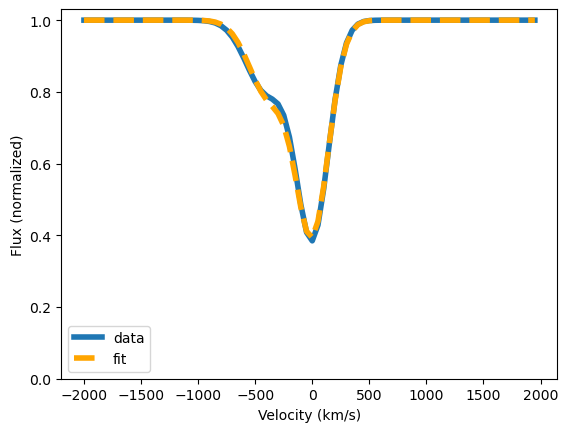

In [7]:
plt.plot(x,y, linewidth= 4, label='data')
plt.plot(x, fitProfile, color='orange', ls ='--', lw=4, label='fit')
plt.legend()
plt.ylim([0,None])
plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux (normalized)")